### Attempt to Create a Regression
- Training period:  2020-01-01 → 2024-12-31  (5 years to learn patterns)
- Testing period:   2025-01-01 → 2026-06-06  (live test — did it actually work?)
##### Step 1: Capture Historical Data 

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Your stock universe
stock_tickers = ['NVDA','AMD','AVGO','ARM','MU','MRVL','TSM',
                 'ASML','AMAT','LRCX','KLAC','SNPS',
                 'TXN','QCOM','INTC','ON']

ticker_group = {
    'NVDA':'AI Chip Pure Play', 'AMD':'AI Chip Pure Play',
    'AVGO':'AI Chip Pure Play', 'ARM':'AI Chip Pure Play',
    'MU':'AI Chip Pure Play',   'MRVL':'AI Chip Pure Play',
    'TSM':'AI Chip Pure Play',  'ASML':'AI Chip Enabler',
    'AMAT':'AI Chip Enabler',   'LRCX':'AI Chip Enabler',
    'KLAC':'AI Chip Enabler',   'SNPS':'AI Chip Enabler',
    'TXN':'Non-AI Control',     'QCOM':'Non-AI Control',
    'INTC':'Non-AI Control',    'ON':'Non-AI Control',
}

In [28]:
# ── Download all daily prices upfront ─────────────────────────────────
# We pull this once and reuse it for all 4 new features
# Avoids making hundreds of individual yfinance calls

print("Downloading 5 years of daily prices for all tickers...")

all_tickers_with_bench = stock_tickers + ['SPY']

raw_prices = yf.download(
    all_tickers_with_bench,
    start='2019-01-01',   # one extra year back for momentum calc
    end='2026-06-06',
    auto_adjust=True,
    progress=True
)

# Handle MultiIndex — flatten to simple ticker → price Series
if isinstance(raw_prices.columns, pd.MultiIndex):
    prices_df = raw_prices['Close']
else:
    prices_df = raw_prices[['Close']]

print(f"Price data shape: {prices_df.shape}")
print(f"Tickers available: {prices_df.columns.tolist()}")
print(f"Date range: {prices_df.index[0].date()} → {prices_df.index[-1].date()}")

[******                12%                       ]  2 of 17 completed

[*********************100%***********************]  17 of 17 completed


Price data shape: (1867, 17)
Tickers available: ['AMAT', 'AMD', 'ARM', 'ASML', 'AVGO', 'INTC', 'KLAC', 'LRCX', 'MRVL', 'MU', 'NVDA', 'ON', 'QCOM', 'SNPS', 'SPY', 'TSM', 'TXN']
Date range: 2019-01-02 → 2026-06-05


##### Step 2: Building Histroical Dataset 

In [9]:
def get_annual_fundamentals_v3(ticker, year):
    """
    Fixed version:
    - Handles MultiIndex price columns
    - Uses exact field names from yfinance output
    - Accounts for non-Dec fiscal year ends
    """
    try:
        stock  = yf.Ticker(ticker)
        income = stock.financials
        balance= stock.balance_sheet

        if income is None or income.empty:
            print(f'    {ticker} {year}: no income data')
            return None

        # ── Find closest fiscal year column ──────────────────────
        # Use Jan 31 of following year as target 
        # (handles NVDA fiscal year + most others)
        target = pd.Timestamp(f'{year+1}-01-31')
        col    = min(income.columns, 
                     key=lambda d: abs(d - target))
        
        # Safety check — don't use a column more than 6 months away
        if abs((col - target).days) > 180:
            print(f'    {ticker} {year}: no close fiscal year column')
            return None

        # ── Income statement fields ───────────────────────────────
        def get_field(df, names):
            """Return first matching field value at col, or None."""
            for name in names:
                if name in df.index:
                    val = df.loc[name, col]
                    if pd.notna(val) and val != 0:
                        return float(val)
            return None

        revenue      = get_field(income, ['Total Revenue', 'Operating Revenue'])
        gross_profit = get_field(income, ['Gross Profit'])
        net_income   = get_field(income, ['Net Income', 
                                          'Net Income Common Stockholders'])
        ebitda       = get_field(income, ['EBITDA', 'Normalized EBITDA'])
        
        # ── Prior year revenue for growth rate ───────────────────
        cols_sorted  = sorted(income.columns, reverse=True)
        col_idx      = cols_sorted.index(col)
        prior_col    = cols_sorted[col_idx + 1] \
                       if col_idx + 1 < len(cols_sorted) else None
        prior_rev    = None
        if prior_col is not None and 'Total Revenue' in income.index:
            pv = income.loc['Total Revenue', prior_col]
            prior_rev = float(pv) if pd.notna(pv) and pv != 0 else None

        # ── Balance sheet ─────────────────────────────────────────
        total_debt, cash = 0.0, 0.0
        if not balance.empty:
            bal_col = min(balance.columns,
                          key=lambda d: abs(d - target))
            
            def get_bal(names):
                for name in names:
                    if name in balance.index:
                        val = balance.loc[name, bal_col]
                        if pd.notna(val):
                            return float(val)
                return 0.0
            
            total_debt = get_bal(['Total Debt', 'Long Term Debt'])
            cash       = get_bal(['Cash And Cash Equivalents',
                                  'Cash Cash Equivalents And Short Term Investments',
                                  'Cash'])

        # ── Derived fundamental metrics ───────────────────────────
        rev_growth   = ((revenue / prior_rev) - 1) * 100 \
                       if revenue and prior_rev else None
        gross_margin = (gross_profit / revenue) * 100 \
                       if gross_profit and revenue else None

        # ── Price data — FIXED for MultiIndex columns ─────────────
        def get_price(tkr, start, end):
            """Download price, handle MultiIndex, return scalar."""
            df = yf.download(tkr, start=start, end=end,
                             progress=False, auto_adjust=True)
            if df.empty:
                return None
            # Handle MultiIndex: ('Close', 'NVDA') → scalar
            if isinstance(df.columns, pd.MultiIndex):
                close = df['Close'][tkr]
            else:
                close = df['Close']
            return float(close.dropna().iloc[0]) \
                   if not close.dropna().empty else None

        # Market cap at START of year
        price_jan = get_price(ticker,
                              f'{year}-01-02',
                              f'{year}-01-15')
        shares    = stock.info.get('sharesOutstanding')
        mkt_cap   = price_jan * shares \
                    if price_jan and shares else None

        # Forward return — price at start vs end of NEXT year
        # This is what we're trying to predict
        p_start = get_price(ticker,
                            f'{year+1}-01-02',
                            f'{year+1}-01-15')
        p_end   = get_price(ticker,
                            f'{year+1}-12-15',
                            f'{year+1}-12-31')
        
        # Special case for 2024 — test period ends June 2026
        if year == 2024:
            p_end = get_price(ticker,
                              '2026-05-15',
                              '2026-06-06')

        fwd_return = ((p_end / p_start) - 1) * 100 \
                     if p_start and p_end else None

        # ── Valuation ratios ──────────────────────────────────────
        ev        = (mkt_cap + total_debt - cash) \
                    if mkt_cap else None
        pe_ratio  = (mkt_cap / net_income) \
                    if mkt_cap and net_income and net_income > 0 else None
        ps_ratio  = (mkt_cap / revenue) \
                    if mkt_cap and revenue else None
        ev_ebitda = (ev / ebitda) \
                    if ev and ebitda and ebitda > 0 else None

        result = {
            'Ticker':       ticker,
            'Year':         year,
            'Group':        ticker_group.get(ticker, 'Unknown'),
            'PE_Ratio':     round(pe_ratio,  2) if pe_ratio  else None,
            'PS_Ratio':     round(ps_ratio,  2) if ps_ratio  else None,
            'EV_EBITDA':    round(ev_ebitda, 2) if ev_ebitda else None,
            'Rev_Growth':   round(rev_growth, 1) if rev_growth else None,
            'Gross_Margin': round(gross_margin,1) if gross_margin else None,
            'Fwd_Return':   round(fwd_return, 1) if fwd_return else None,
        }
        
        return result

    except Exception as e:
        import traceback
        print(f'    {ticker} {year} ERROR: {type(e).__name__}: {e}')
        print(f'    {traceback.format_exc().splitlines()[-2]}')
        return None

In [29]:
# ── Four new price-based features ─────────────────────────────────────
#
# Feature 1: Momentum_12M
#   What:    How much did the stock return in the 12 months BEFORE
#            the prediction period starts
#   Why:     Stocks going up tend to keep going up (momentum effect)
#            This would have caught MU and AMD in your test set
#
# Feature 2: Volatility
#   What:    How much did the daily price bounce around last year
#            Annualized standard deviation of daily returns
#   Why:     High volatility stocks behave differently from low vol
#            Helps model distinguish between stable compounders
#            and speculative momentum plays
#
# Feature 3: Price_vs_200MA
#   What:    Is the stock currently trading ABOVE or BELOW its
#            200-day moving average (200-day average price)
#   Why:     Stocks above 200MA are in uptrends → tend to keep rising
#            Stocks below 200MA are in downtrends → tend to keep falling
#            One of the most widely used technical signals
#
# Feature 4: Prior_Sharpe
#   What:    Risk-adjusted return in the prior year
#            = annual return ÷ annual volatility
#   Why:     A stock that went up a lot BUT with low volatility
#            is a stronger signal than one that went up the same
#            amount with wild swings
#            Separates quality momentum from noisy momentum

def get_price_features(ticker, year, prices_df):
    """
    Calculate four price-based features for a ticker
    measured at the START of year (using prior year's prices)
    
    All features look BACKWARD — they use prices from the year BEFORE
    the prediction period so there is no data leakage
    """
    try:
        if ticker not in prices_df.columns:
            return None
            
        series = prices_df[ticker].dropna()
        
        # ── Define the lookback window ────────────────────────────
        # Feature window: full prior calendar year
        # Jan 1 of prior year → Jan 1 of current year
        
        window_start = pd.Timestamp(f'{year-1}-01-02')
        window_end   = pd.Timestamp(f'{year}-01-15')
        
        # Get prices in the window
        window = series.loc[window_start:window_end].dropna()
        
        if len(window) < 50:
            # Not enough data — skip
            return None
        
        # ── Feature 1: Momentum_12M ───────────────────────────────
        # Simple: price at end of window ÷ price at start − 1
        price_start_window = float(window.iloc[0])
        price_end_window   = float(window.iloc[-1])
        
        if price_start_window <= 0:
            return None
            
        momentum = ((price_end_window / price_start_window) - 1) * 100
        
        # ── Feature 2: Volatility ─────────────────────────────────
        # Annualized standard deviation of daily returns
        daily_ret = window.pct_change().dropna()
        
        if len(daily_ret) < 20:
            return None
            
        volatility = float(daily_ret.std() * np.sqrt(252) * 100)
        
        # ── Feature 3: Price vs 200-day moving average ────────────
        # At the END of the window (start of prediction year)
        # how far is the price above/below its 200-day average?
        
        # Need 200 days of history — go back further
        extended_start = pd.Timestamp(f'{year-2}-01-01')
        extended       = series.loc[extended_start:window_end].dropna()
        
        if len(extended) < 200:
            price_vs_200ma = None  # not enough history
        else:
            ma_200         = float(extended.rolling(200).mean().iloc[-1])
            current_price  = float(extended.iloc[-1])
            price_vs_200ma = ((current_price / ma_200) - 1) * 100 \
                             if ma_200 > 0 else None
        
        # ── Feature 4: Prior Sharpe ratio ────────────────────────
        # Risk-adjusted return = annual return ÷ annual volatility
        # Uses same window as momentum and volatility
        
        annual_ret    = ((price_end_window / price_start_window) - 1)
        annual_vol_dec = daily_ret.std() * np.sqrt(252)  # as decimal
        
        prior_sharpe = float(annual_ret / annual_vol_dec) \
                       if annual_vol_dec > 0 else None
        
        return {
            'Momentum_12M':    round(momentum,       1),
            'Volatility':      round(volatility,     1),
            'Price_vs_200MA':  round(price_vs_200ma, 1) \
                               if price_vs_200ma else None,
            'Prior_Sharpe':    round(prior_sharpe,   3) \
                               if prior_sharpe else None,
        }
    
    except Exception as e:
        print(f"    Price features error {ticker} {year}: {e}")
        return None


# ── Quick test on one ticker before using in full loop ─────────────────
test_feats = get_price_features('NVDA', 2023, prices_df)
print("Test — NVDA 2023 price features:")
print(test_feats)
print()
test_feats2 = get_price_features('MU', 2024, prices_df)
print("Test — MU 2024 price features (should show strong momentum):")
print(test_feats2)

Test — NVDA 2023 price features:
{'Momentum_12M': -43.8, 'Volatility': 62.9, 'Price_vs_200MA': 2.5, 'Prior_Sharpe': -0.697}

Test — MU 2024 price features (should show strong momentum):
{'Momentum_12M': 64.7, 'Volatility': 36.0, 'Price_vs_200MA': 19.6, 'Prior_Sharpe': 1.798}


##### Step 3: Loop through stocks and years 

In [30]:
# ── Step 3 — Build dataset with price features added ──────────────────
all_rows = []
errors   = []

for year in [2020, 2021, 2022, 2023, 2024]:
    print(f'\nYear {year}:')
    for ticker in stock_tickers:

        # Skip ARM before IPO
        if ticker == 'ARM' and year < 2023:
            continue

        print(f'  {ticker}...', end=' ', flush=True)

        # ── Get fundamental data (existing function) ───────────────
        row = get_annual_fundamentals_v3(ticker, year)

        if row is None:
            errors.append((ticker, year))
            print('✗ fundamentals failed')
            continue

        # ── Get price features (new function) ─────────────────────
        price_feats = get_price_features(ticker, year, prices_df)

        if price_feats is not None:
            row.update(price_feats)   # merge into same row dict
            print(f"✓  PE={row.get('PE_Ratio')}  "
                  f"mom={price_feats.get('Momentum_12M')}%  "
                  f"fwd={row.get('Fwd_Return')}%")
        else:
            # Keep the row even if price features failed
            # They'll be NaN and dropped later if needed
            row.update({
                'Momentum_12M':   None,
                'Volatility':     None,
                'Price_vs_200MA': None,
                'Prior_Sharpe':   None,
            })
            print(f"✓  PE={row.get('PE_Ratio')}  "
                  f"(no price features)  "
                  f"fwd={row.get('Fwd_Return')}%")

        all_rows.append(row)

raw_df = pd.DataFrame(all_rows) if all_rows else pd.DataFrame()

print(f'\n{"="*50}')
print(f'Rows collected:  {len(all_rows)}')
print(f'Errors:          {len(errors)}')
print(f'\nAll columns now:')
print(raw_df.columns.tolist())
print(f'\nMissing values per column:')
print(raw_df.isnull().sum())


Year 2020:
  NVDA...     NVDA 2020: no close fiscal year column
✗ fundamentals failed
  AMD...     AMD 2020: no close fiscal year column
✗ fundamentals failed
  AVGO...     AVGO 2020: no close fiscal year column
✗ fundamentals failed
  MU...     MU 2020: no close fiscal year column
✗ fundamentals failed
  MRVL...     MRVL 2020: no close fiscal year column
✗ fundamentals failed
  TSM...     TSM 2020: no close fiscal year column
✗ fundamentals failed
  ASML...     ASML 2020: no close fiscal year column
✗ fundamentals failed
  AMAT...     AMAT 2020: no close fiscal year column
✗ fundamentals failed
  LRCX...     LRCX 2020: no close fiscal year column
✗ fundamentals failed
  KLAC... ✓  PE=None  mom=100.5%  fwd=59.3%
  SNPS...     SNPS 2020: no close fiscal year column
✗ fundamentals failed
  TXN...     TXN 2020: no close fiscal year column
✗ fundamentals failed
  QCOM...     QCOM 2020: no close fiscal year column
✗ fundamentals failed
  INTC...     INTC 2020: no close fiscal year column
✗

$ARM: possibly delisted; no price data found  (1d 2023-01-02 -> 2023-01-15) (Yahoo error = "Data doesn't exist for startDate = 1672635600, endDate = 1673758800")

1 Failed download:
['ARM']: possibly delisted; no price data found  (1d 2023-01-02 -> 2023-01-15) (Yahoo error = "Data doesn't exist for startDate = 1672635600, endDate = 1673758800")


✓  PE=None  (no price features)  fwd=110.4%
  MU... ✓  PE=None  mom=-40.1%  fwd=31.9%
  MRVL... ✓  PE=None  mom=-54.3%  fwd=115.3%
  TSM... ✓  PE=0.43  mom=-31.2%  fwd=102.0%
  ASML... ✓  PE=26.2  mom=-16.3%  fwd=1.6%
  AMAT... ✓  PE=10.88  mom=-30.6%  fwd=10.6%
  LRCX... ✓  PE=13.1  mom=-33.8%  fwd=4.9%
  KLAC... ✓  PE=17.25  mom=-2.2%  fwd=18.1%
  SNPS... ✓  PE=49.77  mom=-7.8%  fwd=4.6%
  TXN... ✓  PE=20.59  mom=-3.4%  fwd=15.1%
  QCOM... ✓  PE=14.45  mom=-34.0%  fwd=14.8%
  INTC... ✓  PE=76.7  mom=-41.2%  fwd=-55.8%
  ON... ✓  PE=10.97  mom=-7.2%  fwd=-18.4%

Year 2024:
  NVDA... ✓  PE=15.98  mom=282.4%  fwd=63.0%
  AMD... ✓  PE=137.7  mom=128.9%  fwd=251.6%
  AVGO... ✓  PE=85.07  mom=104.7%  fwd=85.3%
  ARM... ✓  PE=92.94  mom=10.1%  fwd=63.2%
  MU... ✓  PE=118.41  mom=64.7%  fwd=732.9%
  MRVL... ✓  PE=None  mom=83.7%  fwd=56.4%
  TSM... ✓  PE=0.44  mom=39.4%  fwd=103.9%
  ASML... ✓  PE=35.73  mom=31.1%  fwd=117.2%
  AMAT... ✓  PE=16.74  mom=57.8%  fwd=169.4%
  LRCX... ✓  PE=17.13

##### Step 4: Clean and Prepare Data 

In [31]:
# ── Updated feature list — fundamentals + price features ──────────────
FEATURES = [
    # Original fundamental features
    'PE_Ratio',
    'PS_Ratio',
    'EV_EBITDA',
    'Rev_Growth',
    'Gross_Margin',
    # New price-based features
    'Momentum_12M',
    'Volatility',
    'Price_vs_200MA',
    'Prior_Sharpe',
]
TARGET = 'Fwd_Return'

print(f"Features: {FEATURES}")
print(f"Total features: {len(FEATURES)}")
print(f"\nRaw rows collected: {len(raw_df)}")
print(f"Columns: {raw_df.columns.tolist()}")
print(f"\nMissing values:")
print(raw_df.isnull().sum())
print(f"\nSample data:")
print(raw_df[['Ticker','Year'] + FEATURES + [TARGET]].head(10))

Features: ['PE_Ratio', 'PS_Ratio', 'EV_EBITDA', 'Rev_Growth', 'Gross_Margin', 'Momentum_12M', 'Volatility', 'Price_vs_200MA', 'Prior_Sharpe']
Total features: 9

Raw rows collected: 61
Columns: ['Ticker', 'Year', 'Group', 'PE_Ratio', 'PS_Ratio', 'EV_EBITDA', 'Rev_Growth', 'Gross_Margin', 'Fwd_Return', 'Momentum_12M', 'Volatility', 'Price_vs_200MA', 'Prior_Sharpe']

Missing values:
Ticker             0
Year               0
Group              0
PE_Ratio          18
PS_Ratio          13
EV_EBITDA         13
Rev_Growth        27
Gross_Margin      12
Fwd_Return         0
Momentum_12M       1
Volatility         1
Price_vs_200MA     2
Prior_Sharpe       1
dtype: int64

Sample data:
  Ticker  Year  PE_Ratio  PS_Ratio  EV_EBITDA  Rev_Growth  Gross_Margin  \
0   KLAC  2020       NaN       NaN        NaN         NaN           NaN   
1   NVDA  2021       NaN       NaN        NaN         NaN           NaN   
2    AMD  2021       NaN       NaN        NaN         NaN           NaN   
3   AVGO  2021   

In [32]:
# Drop rows missing target or any feature
model_df = raw_df.dropna(subset=[TARGET] + FEATURES).copy()

print(f"Rows before cleaning: {len(raw_df)}")
print(f"Rows after dropping NaN: {len(model_df)}")

# Remove extreme outliers that would dominate the regression
# These are real values but statistically they pull the line unfairly
before = len(model_df)
model_df = model_df[
    (model_df['PE_Ratio']  < 500) &
    (model_df['PE_Ratio']  > 0)   &
    (model_df['EV_EBITDA'] < 400) &
    (model_df['EV_EBITDA'] > 0)   &
    (model_df['PS_Ratio']  < 100) &
    (model_df['PS_Ratio']  > 0)
]
print(f"Rows after outlier removal: {len(model_df)}")
print(f"Rows removed as outliers: {before - len(model_df)}")
print(f"\nData by year:")
print(model_df['Year'].value_counts().sort_index())
print(f"\nData by group:")
print(model_df['Group'].value_counts())
print(f"\nFeature summary stats:")
print(model_df[FEATURES + [TARGET]].describe().round(2))

Rows before cleaning: 61
Rows after dropping NaN: 28
Rows after outlier removal: 26
Rows removed as outliers: 2

Data by year:
Year
2022     2
2023    12
2024    12
Name: count, dtype: int64

Data by group:
Group
AI Chip Enabler      12
AI Chip Pure Play     7
Non-AI Control        7
Name: count, dtype: int64

Feature summary stats:
       PE_Ratio  PS_Ratio  EV_EBITDA  Rev_Growth  Gross_Margin  Momentum_12M  \
count     26.00     26.00      26.00       26.00         26.00         26.00   
mean      37.59      6.23      18.14       15.81         55.43         29.33   
std       37.73      3.17      10.83       36.04         13.12         71.07   
min       10.88      2.39       7.71      -19.00         22.40        -52.70   
25%       16.00      3.86      11.84       -5.85         47.15        -14.70   
50%       18.48      5.08      13.66        5.35         53.50         11.75   
75%       40.59      8.48      20.38       21.58         62.40         57.02   
max      137.70     15.59

##### Step 5: Split into train and test 

In [33]:
# Training: fundamentals from 2020-2023 predicting 2021-2024 returns
# Testing:  fundamentals from 2024 predicting 2025-2026 returns

train_df = model_df[model_df['Year'] <= 2023].copy()
test_df  = model_df[model_df['Year'] == 2024].copy()

print(f'Training samples: {len(train_df)}')
print(f'Testing samples:  {len(test_df)}')
print(f'\nTraining target distribution:')
print(train_df[TARGET].describe().round(1))
print(f'\nTesting target distribution:')
print(test_df[TARGET].describe().round(1))

# Separate features and target
X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

# Scale features — important for regression
# Each feature is on different scale (PE is 30x, margins are 0-100%)
# Scaling puts them all on same footing
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # use SAME scaler as training

print('\nFeatures scaled ✓')
print('(StandardScaler: each feature → mean=0, std=1)')

Training samples: 14
Testing samples:  12

Training target distribution:
count     14.0
mean      31.4
std       61.9
min      -55.8
25%        2.4
50%       12.7
75%       47.5
max      174.1
Name: Fwd_Return, dtype: float64

Testing target distribution:
count     12.0
mean     174.5
std      196.5
min        4.1
25%       67.6
50%      101.2
75%      202.5
max      732.9
Name: Fwd_Return, dtype: float64

Features scaled ✓
(StandardScaler: each feature → mean=0, std=1)


##### Step 6: Run Regression

In [34]:
# Before running multi-variable regression
# check each feature individually — which ones have signal?

print('Individual feature regressions vs forward return:')
print('=' * 65)
print(f'{"Feature":<20} {"Slope":>8} {"R²":>8} {"p-value":>10} {"Signal"}')
print('-' * 65)

single_results = {}

for feature in FEATURES:
    x = train_df[feature].values
    y = train_df[TARGET].values
    
    # Remove any remaining NaN pairs
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    
    slope, intercept, r_val, p_val, se = stats.linregress(x, y)
    r2 = r_val ** 2
    
    signal = '✓ significant' if p_val < 0.05 else \
             '~ marginal'    if p_val < 0.10 else \
             '✗ weak'
    
    single_results[feature] = {
        'slope': slope, 'r2': r2, 'p_value': p_val
    }
    
    print(f'{feature:<20} {slope:>8.3f} {r2:>8.3f} {p_val:>10.4f}  {signal}')

print()
print('R² interpretation:')
print('  0.00–0.05 = very weak signal')
print('  0.05–0.15 = weak but real')
print('  0.15–0.35 = moderate — useful')
print('  0.35+     = strong')

Individual feature regressions vs forward return:
Feature                 Slope       R²    p-value Signal
-----------------------------------------------------------------
PE_Ratio               -0.795    0.170     0.1427  ✗ weak
PS_Ratio                5.877    0.057     0.4107  ✗ weak
EV_EBITDA              -1.708    0.051     0.4373  ✗ weak
Rev_Growth              1.183    0.481     0.0060  ✓ significant
Gross_Margin            2.725    0.280     0.0518  ~ marginal
Momentum_12M            0.402    0.054     0.4236  ✗ weak
Volatility              0.313    0.002     0.8701  ✗ weak
Price_vs_200MA          1.497    0.091     0.2951  ✗ weak
Prior_Sharpe           22.596    0.085     0.3129  ✗ weak

R² interpretation:
  0.00–0.05 = very weak signal
  0.05–0.15 = weak but real
  0.15–0.35 = moderate — useful
  0.35+     = strong


##### Step 7: Run Multiple Regression

In [35]:
# Multiple regression — all features together
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Training performance
y_train_pred = model.predict(X_train_scaled)
train_r2     = r2_score(y_train, y_train_pred)
train_mae    = mean_absolute_error(y_train, y_train_pred)

# Test performance — the real question
y_test_pred  = model.predict(X_test_scaled)
test_r2      = r2_score(y_test, y_test_pred)
test_mae     = mean_absolute_error(y_test, y_test_pred)

print('Multiple regression results:')
print('=' * 50)
print(f'\nTraining performance (2020-2023):')
print(f'  R²:  {train_r2:.3f}')
print(f'  MAE: {train_mae:.1f}%  (average prediction error)')

print(f'\nTest performance (2024 → 2025 returns):')
print(f'  R²:  {test_r2:.3f}')
print(f'  MAE: {test_mae:.1f}%')

print(f'\nFeature coefficients (scaled):')
print(f'  (positive = higher value predicts higher return)')
print(f'  (negative = higher value predicts lower return)')
for feat, coef in zip(FEATURES, model.coef_):
    direction = '↑' if coef > 0 else '↓'
    print(f'  {feat:<20} {coef:>8.3f}  {direction}')

print(f'\n  Intercept: {model.intercept_:.2f}%')

Multiple regression results:

Training performance (2020-2023):
  R²:  0.783
  MAE: 19.5%  (average prediction error)

Test performance (2024 → 2025 returns):
  R²:  -0.344
  MAE: 148.8%

Feature coefficients (scaled):
  (positive = higher value predicts higher return)
  (negative = higher value predicts lower return)
  PE_Ratio                2.892  ↑
  PS_Ratio               19.310  ↑
  EV_EBITDA             -38.128  ↓
  Rev_Growth             27.224  ↑
  Gross_Margin           15.198  ↑
  Momentum_12M         -139.761  ↓
  Volatility            -20.775  ↓
  Price_vs_200MA         -7.976  ↓
  Prior_Sharpe          149.924  ↑

  Intercept: 31.44%


##### Step 8: Visualize Predictions vs Actual 

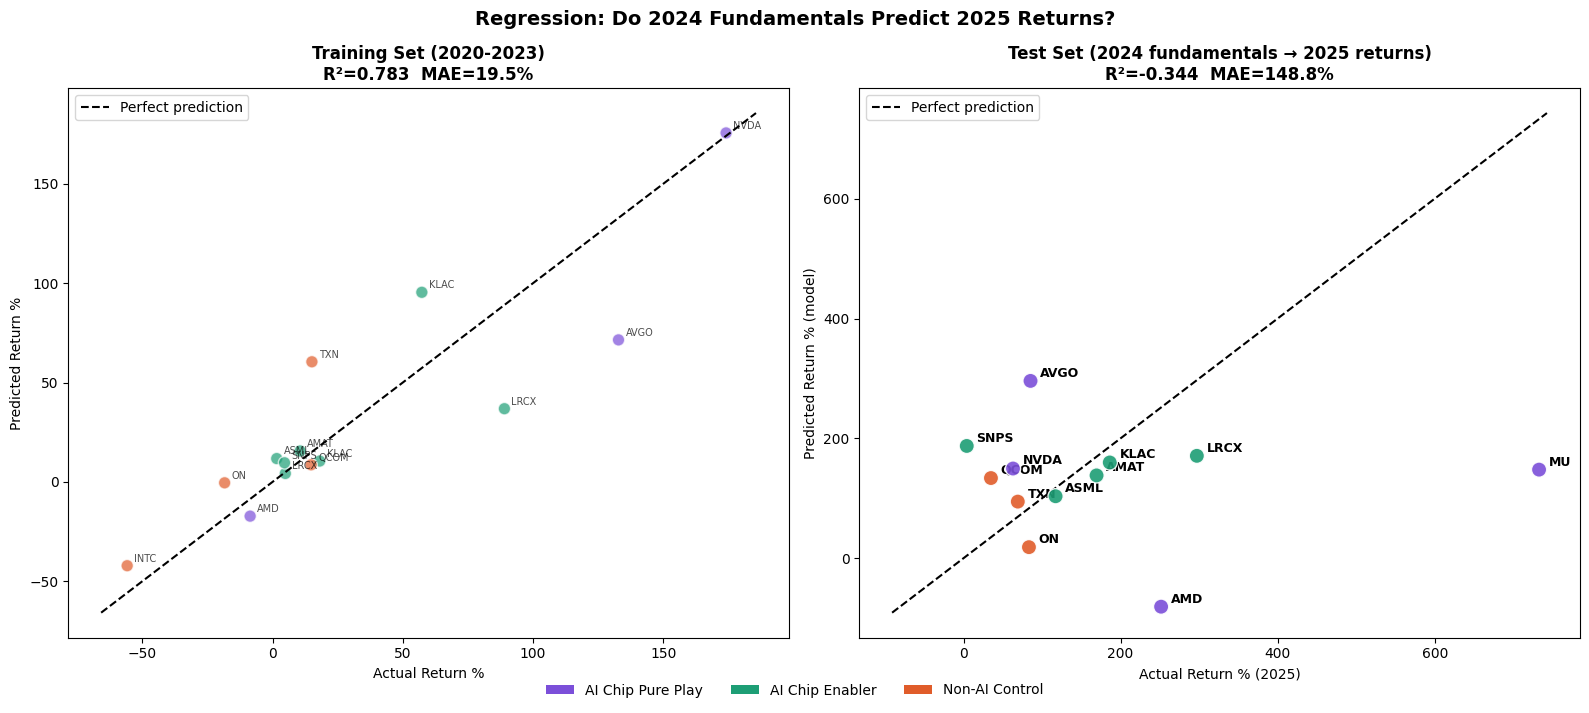

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Chart 1: Training fit ──────────────────────────────────────────────
ax = axes[0]
colors_train = [{'AI Chip Pure Play':'#7B4FD9',
                 'AI Chip Enabler':'#1D9E75',
                 'Non-AI Control':'#E05C2A'}.get(g,'gray')
                for g in train_df['Group']]

ax.scatter(y_train, y_train_pred, c=colors_train, s=80,
           alpha=0.7, edgecolors='white')

# Perfect prediction line
lims = [min(y_train.min(), y_train_pred.min()) - 10,
        max(y_train.max(), y_train_pred.max()) + 10]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')

# Label each point
for i, (actual, pred, ticker) in enumerate(
    zip(y_train, y_train_pred, train_df['Ticker'])
):
    ax.annotate(ticker, (actual, pred),
                textcoords='offset points',
                xytext=(5, 3), fontsize=7, alpha=0.7)

ax.set_xlabel('Actual Return %')
ax.set_ylabel('Predicted Return %')
ax.set_title(f'Training Set (2020-2023)\nR²={train_r2:.3f}  MAE={train_mae:.1f}%',
             fontweight='bold')
ax.legend()

# ── Chart 2: Test predictions vs actual ───────────────────────────────
ax = axes[1]
colors_test = [{'AI Chip Pure Play':'#7B4FD9',
                'AI Chip Enabler':'#1D9E75',
                'Non-AI Control':'#E05C2A'}.get(g,'gray')
               for g in test_df['Group']]

ax.scatter(y_test, y_test_pred, c=colors_test, s=120,
           alpha=0.9, edgecolors='white', zorder=5)

# Perfect prediction line
lims = [min(y_test.min(), y_test_pred.min()) - 10,
        max(y_test.max(), y_test_pred.max()) + 10]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')

# Label every test point — small enough sample to show all
for actual, pred, ticker in zip(y_test, y_test_pred, test_df['Ticker']):
    ax.annotate(ticker, (actual, pred),
                textcoords='offset points',
                xytext=(7, 3), fontsize=9, fontweight='bold')

ax.set_xlabel('Actual Return % (2025)')
ax.set_ylabel('Predicted Return % (model)')
ax.set_title(f'Test Set (2024 fundamentals → 2025 returns)\nR²={test_r2:.3f}  MAE={test_mae:.1f}%',
             fontweight='bold')
ax.legend()

from matplotlib.patches import Patch
legend_el = [Patch(facecolor=c, label=g) for g, c in
             [('AI Chip Pure Play','#7B4FD9'),
              ('AI Chip Enabler','#1D9E75'),
              ('Non-AI Control','#E05C2A')]]
fig.legend(handles=legend_el, loc='lower center', ncol=3,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Regression: Do 2024 Fundamentals Predict 2025 Returns?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

##### Step 9: Residual Anaylsis 

Test set — actual vs predicted:
   Ticker              Group  Fwd_Return  Predicted  Residual
49     MU  AI Chip Pure Play       732.9      147.8     585.1
46    AMD  AI Chip Pure Play       251.6      -81.0     332.6
54   LRCX    AI Chip Enabler       297.1      170.8     126.3
60     ON     Non-AI Control        83.3       18.4      64.9
53   AMAT    AI Chip Enabler       169.4      138.1      31.3
55   KLAC    AI Chip Enabler       186.2      159.7      26.5
52   ASML    AI Chip Enabler       117.2      103.4      13.8
57    TXN     Non-AI Control        69.1       94.4     -25.3
45   NVDA  AI Chip Pure Play        63.0      149.6     -86.6
58   QCOM     Non-AI Control        34.9      133.7     -98.8
56   SNPS    AI Chip Enabler         4.1      187.3    -183.2
47   AVGO  AI Chip Pure Play        85.3      295.9    -210.6

Biggest overestimates (model too optimistic):
   Ticker  Fwd_Return  Predicted  Residual
47   AVGO        85.3      295.9    -210.6
56   SNPS         4.1      18

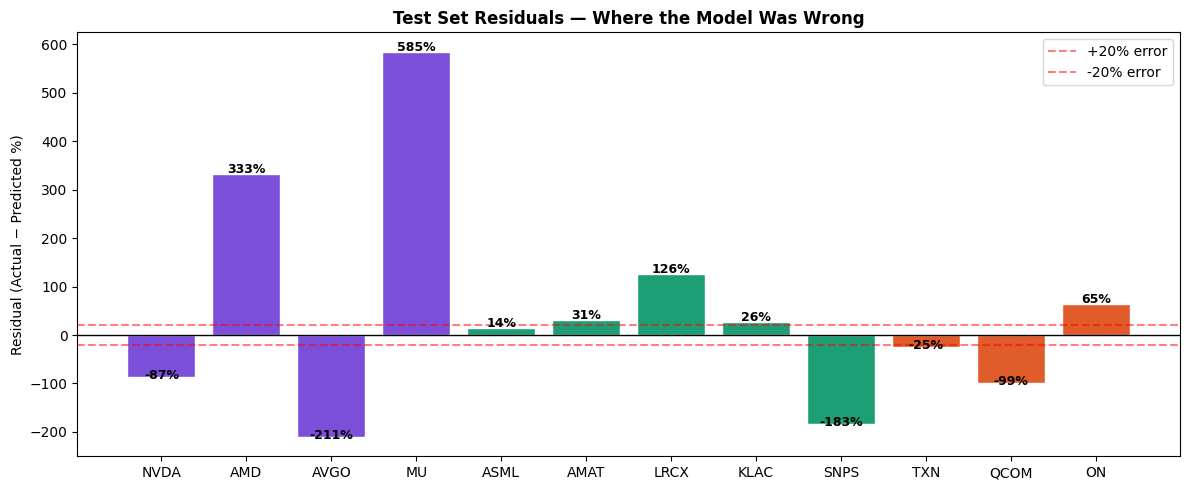

In [37]:
# Residuals = actual return minus predicted return
# Large residuals = stocks the model got very wrong
# Understanding WHY it got them wrong is often the most valuable finding

test_df = test_df.copy()
test_df['Predicted']  = y_test_pred
test_df['Residual']   = y_test - y_test_pred
test_df['Abs_Error']  = test_df['Residual'].abs()

print('Test set — actual vs predicted:')
print('=' * 70)
display_cols = ['Ticker','Group','Fwd_Return','Predicted','Residual']
print(test_df[display_cols].sort_values('Residual', ascending=False).round(1).to_string())

print(f'\nBiggest overestimates (model too optimistic):')
print(test_df.nsmallest(3, 'Residual')[['Ticker','Fwd_Return','Predicted','Residual']].round(1))

print(f'\nBiggest underestimates (model missed upside):')
print(test_df.nlargest(3, 'Residual')[['Ticker','Fwd_Return','Predicted','Residual']].round(1))

# Plot residuals
fig, ax = plt.subplots(figsize=(12, 5))
colors  = [{'AI Chip Pure Play':'#7B4FD9',
            'AI Chip Enabler':'#1D9E75',
            'Non-AI Control':'#E05C2A'}.get(g,'gray')
           for g in test_df['Group']]

bars = ax.bar(test_df['Ticker'], test_df['Residual'],
              color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.axhline(20,  color='red', linestyle='--', alpha=0.5, label='+20% error')
ax.axhline(-20, color='red', linestyle='--', alpha=0.5, label='-20% error')

for bar, val in zip(bars, test_df['Residual']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (2 if val >= 0 else -4),
            f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Residual (Actual − Predicted %)')
ax.set_title('Test Set Residuals — Where the Model Was Wrong',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('residuals.png', dpi=150, bbox_inches='tight')
plt.show()

##### Step 10: Conclusion

In [38]:
print('=' * 60)
print('REGRESSION FINDINGS')
print('=' * 60)

print(f'''
TRAINING PERFORMANCE (2020-2023):
  R² = {train_r2:.3f}
  The model explains {train_r2*100:.1f}% of return variance
  in the training period.

OUT-OF-SAMPLE TEST (2024 → 2025 returns):
  R² = {test_r2:.3f}
  MAE = {test_mae:.1f}% average prediction error

WHAT THIS MEANS:
  If test R² > 0.15:  model has genuine predictive signal
  If test R² < 0.05:  fundamentals alone don't predict returns
                      in this sector/period
  If train R² >> test R²: model overfit training data

MOST PREDICTIVE FEATURES (by individual R²):''')

sorted_features = sorted(single_results.items(),
                          key=lambda x: x[1]['r2'], reverse=True)
for feat, res in sorted_features:
    direction = 'negative' if res['slope'] < 0 else 'positive'
    print(f'  {feat:<20} R²={res["r2"]:.3f}  '
          f'({direction} relationship)  '
          f'p={res["p_value"]:.4f}')

print(f'''
KEY FINDING:
  Stocks the model got most wrong are the most interesting.
  Large positive residuals = model underestimated → 
    something beyond fundamentals drove the return
    (narrative, momentum, macro event)
  Large negative residuals = model overestimated →
    fundamentals looked good but something went wrong
    (execution, competition, sector rotation)

NOTE: This is exploratory analysis only.
Small sample size (n={len(model_df)}) means results
have wide confidence intervals. Do not use for
actual investment decisions.
''')

REGRESSION FINDINGS

TRAINING PERFORMANCE (2020-2023):
  R² = 0.783
  The model explains 78.3% of return variance
  in the training period.

OUT-OF-SAMPLE TEST (2024 → 2025 returns):
  R² = -0.344
  MAE = 148.8% average prediction error

WHAT THIS MEANS:
  If test R² > 0.15:  model has genuine predictive signal
  If test R² < 0.05:  fundamentals alone don't predict returns
                      in this sector/period
  If train R² >> test R²: model overfit training data

MOST PREDICTIVE FEATURES (by individual R²):
  Rev_Growth           R²=0.481  (positive relationship)  p=0.0060
  Gross_Margin         R²=0.280  (positive relationship)  p=0.0518
  PE_Ratio             R²=0.170  (negative relationship)  p=0.1427
  Price_vs_200MA       R²=0.091  (positive relationship)  p=0.2951
  Prior_Sharpe         R²=0.085  (positive relationship)  p=0.3129
  PS_Ratio             R²=0.057  (positive relationship)  p=0.4107
  Momentum_12M         R²=0.054  (positive relationship)  p=0.4236
  EV_EBITDA